In [ ]:
# 📘 STAGE 4 — BASELINE MODELS

## 1. Purpose of Stage 4

In this stage, we build the **baseline machine-learning models** for the UCI Bank Marketing dataset.

A **baseline model** is a model trained using a standard configuration before applying advanced techniques such as:

- Class weighting
- SMOTE
- Hyperparameter Optimization (HPO)
- Multi-objective HPO
- Threshold optimization
- Robustness analysis
- Explainable AI (XAI)

The main purpose of a baseline is to establish a **fixed reference point**.

Our research question later will be:

> **Does imbalance handling and hyperparameter optimization actually improve model performance compared with standard, untuned models?**

Therefore, before performing HPO or imbalance handling, we first need to understand how standard models perform.

---

# 2. Dataset Used

We are using the:

> **UCI Bank Marketing Dataset — `bank-full.csv`**

The dataset contains customer and campaign-related information from a bank marketing campaign.

The target variable is:

```text
y

In [9]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load dataset
data_path = "../data/raw/bank-full.csv"
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Separate features and target
X = df.drop(columns=["y"]).copy()
y = df["y"].map({
    "no": 0,
    "yes": 1
})

# Identify feature types
numerical_columns = X.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X.select_dtypes(include="object").columns.tolist()

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_columns
        ),
        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ]
)

print("\nStage 4 setup completed successfully!")

print("\nTraining data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Dataset loaded successfully!
Dataset shape: (45211, 17)

Stage 4 setup completed successfully!

Training data shape:
(36168, 16)

Testing data shape:
(9043, 16)

Training target distribution:
y
0    31937
1     4231
Name: count, dtype: int64

Testing target distribution:
y
0    7985
1    1058
Name: count, dtype: int64


In [3]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression baseline trained successfully!")

# Generate predictions
y_pred_logistic = logistic_model.predict(X_test)

# Generate probability predictions
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("\nPredictions generated successfully!")

print("Number of predictions:", len(y_pred_logistic))
print("Number of probability predictions:", len(y_prob_logistic))

print("\nFirst 10 predicted classes:")
print(y_pred_logistic[:10])

print("\nFirst 10 predicted probabilities:")
print(np.round(y_prob_logistic[:10], 4))

Logistic Regression baseline trained successfully!

Predictions generated successfully!
Number of predictions: 9043
Number of probability predictions: 9043

First 10 predicted classes:
[0 0 0 0 1 0 0 0 0 0]

First 10 predicted probabilities:
[0.0961 0.059  0.0072 0.1062 0.51   0.0752 0.0407 0.1084 0.0142 0.0167]


In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# Calculate baseline metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

logistic_pr_auc = average_precision_score(
    y_test,
    y_prob_logistic
)

logistic_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_logistic
)

# Confusion matrix
logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

# Display results
print("=" * 60)
print("LOGISTIC REGRESSION — BASELINE RESULTS")
print("=" * 60)

print(f"\nAccuracy:           {logistic_accuracy:.4f}")
print(f"Precision:          {logistic_precision:.4f}")
print(f"Recall:             {logistic_recall:.4f}")
print(f"F1-score:           {logistic_f1:.4f}")
print(f"ROC-AUC:            {logistic_roc_auc:.4f}")
print(f"PR-AUC:             {logistic_pr_auc:.4f}")
print(f"Balanced Accuracy:  {logistic_balanced_accuracy:.4f}")

print("\nConfusion Matrix:")
print(logistic_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Subscription (0)", "Subscription (1)"],
        zero_division=0
    )
)

LOGISTIC REGRESSION — BASELINE RESULTS

Accuracy:           0.9022
Precision:          0.6543
Recall:             0.3488
F1-score:           0.4550
ROC-AUC:            0.9109
PR-AUC:             0.5591
Balanced Accuracy:  0.6622

Confusion Matrix:
[[7790  195]
 [ 689  369]]

Classification Report:
                     precision    recall  f1-score   support

No Subscription (0)       0.92      0.98      0.95      7985
   Subscription (1)       0.65      0.35      0.45      1058

           accuracy                           0.90      9043
          macro avg       0.79      0.66      0.70      9043
       weighted avg       0.89      0.90      0.89      9043



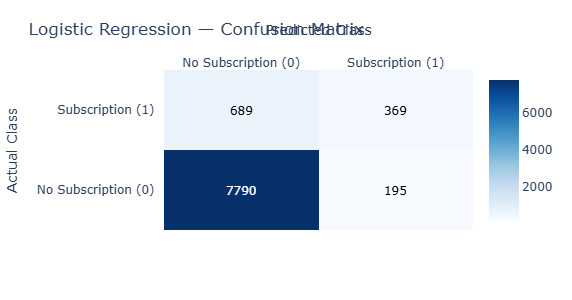

In [6]:
import plotly.figure_factory as ff

# Create confusion matrix labels
cm_labels = [
    "No Subscription (0)",
    "Subscription (1)"
]

# Create interactive confusion matrix
fig = ff.create_annotated_heatmap(
    z=logistic_cm,
    x=cm_labels,
    y=cm_labels,
    annotation_text=[
        [str(value) for value in row]
        for row in logistic_cm
    ],
    colorscale="Blues",
    showscale=True
)

fig.update_layout(
    title="Logistic Regression — Confusion Matrix",
    xaxis_title="Predicted Class",
    yaxis_title="Actual Class",
    width=500,
    height=300,
    margin=dict(l=70, r=30, t=70, b=70)
)

fig.show()

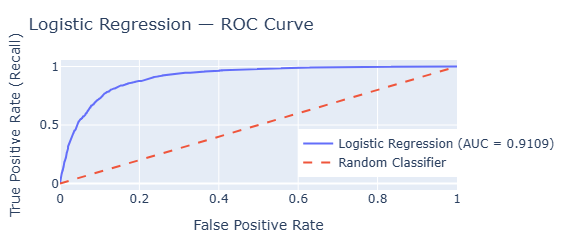

In [12]:
from sklearn.metrics import roc_curve

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_logistic
)

# Create ROC curve
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=fpr,
        y=tpr,
        mode="lines",
        name=f"Logistic Regression (AUC = {logistic_roc_auc:.4f})"
    )
)

# Random classifier reference line
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Random Classifier",
        line=dict(dash="dash")
    )
)

fig.update_layout(
    title="Logistic Regression — ROC Curve",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate (Recall)",
    width=500,
    height=250,
    margin=dict(l=60, r=30, t=60, b=60),
    legend=dict(
        x=0.60,
        y=0.10
    )
)

fig.show()

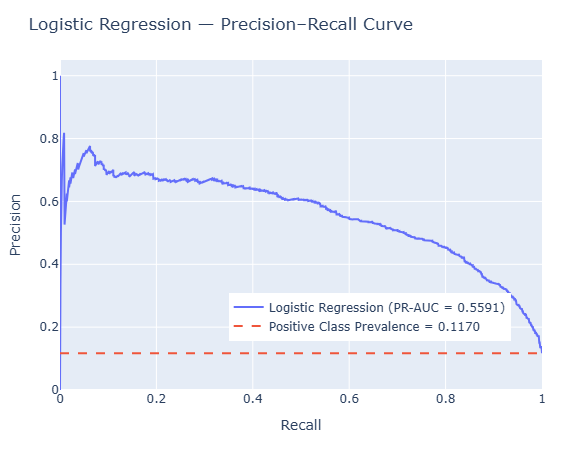

Logistic Regression PR-AUC: 0.5591
Positive class prevalence: 0.1170


In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall values
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob_logistic
)

# Calculate Average Precision / PR-AUC
logistic_pr_auc = average_precision_score(
    y_test,
    y_prob_logistic
)

# Create interactive Precision-Recall curve
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=recall,
        y=precision,
        mode="lines",
        name=f"Logistic Regression (PR-AUC = {logistic_pr_auc:.4f})",
        hovertemplate=(
            "Recall: %{x:.4f}<br>"
            "Precision: %{y:.4f}"
            "<extra></extra>"
        )
    )
)

# Positive-class prevalence baseline
positive_prevalence = y_test.mean()

fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[positive_prevalence, positive_prevalence],
        mode="lines",
        name=f"Positive Class Prevalence = {positive_prevalence:.4f}",
        line=dict(dash="dash")
    )
)

fig.update_layout(
    title="Logistic Regression — Precision–Recall Curve",
    xaxis_title="Recall",
    yaxis_title="Precision",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.05]),
    width=700,
    height=450,
    margin=dict(l=60, r=30, t=60, b=60),
    legend=dict(
        x=0.35,
        y=0.15
    )
)

fig.show()

print(f"Logistic Regression PR-AUC: {logistic_pr_auc:.4f}")
print(f"Positive class prevalence: {positive_prevalence:.4f}")

In [14]:
# Create baseline results table for Logistic Regression

baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [logistic_accuracy],
    "Precision": [logistic_precision],
    "Recall": [logistic_recall],
    "F1_Score": [logistic_f1],
    "ROC_AUC": [logistic_roc_auc],
    "PR_AUC": [logistic_pr_auc],
    "Balanced_Accuracy": [logistic_balanced_accuracy]
})

print("=" * 70)
print("BASELINE RESULTS — LOGISTIC REGRESSION")
print("=" * 70)

display(
    baseline_results.round(4)
)

BASELINE RESULTS — LOGISTIC REGRESSION


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Logistic Regression,0.9022,0.6543,0.3488,0.455,0.9109,0.5591,0.6622


In [15]:
import os

# Make sure the results directory exists
os.makedirs("../results/metrics", exist_ok=True)

baseline_results_path = "../results/metrics/baseline_results.csv"

baseline_results.to_csv(
    baseline_results_path,
    index=False
)

print("Baseline results saved successfully!")
print("\nSaved at:")
print(baseline_results_path)

print("\nSaved results:")
display(baseline_results.round(4))

Baseline results saved successfully!

Saved at:
../results/metrics/baseline_results.csv

Saved results:


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Logistic Regression,0.9022,0.6543,0.3488,0.455,0.9109,0.5591,0.6622


In [16]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree baseline model
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

# Train the model
decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree baseline trained successfully!")

# Generate class predictions
y_pred_tree = decision_tree_model.predict(X_test)

# Generate probability predictions
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

print("\nPredictions generated successfully!")

print("Number of predictions:", len(y_pred_tree))
print("Number of probability predictions:", len(y_prob_tree))

print("\nFirst 10 predicted classes:")
print(y_pred_tree[:10])

print("\nFirst 10 predicted probabilities:")
print(np.round(y_prob_tree[:10], 4))

Decision Tree baseline trained successfully!

Predictions generated successfully!
Number of predictions: 9043
Number of probability predictions: 9043

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [17]:
# Calculate Decision Tree baseline metrics

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

tree_pr_auc = average_precision_score(
    y_test,
    y_prob_tree
)

tree_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_tree
)

# Confusion matrix
tree_cm = confusion_matrix(
    y_test,
    y_pred_tree
)

# Display results
print("=" * 60)
print("DECISION TREE — BASELINE RESULTS")
print("=" * 60)

print(f"\nAccuracy:           {tree_accuracy:.4f}")
print(f"Precision:          {tree_precision:.4f}")
print(f"Recall:             {tree_recall:.4f}")
print(f"F1-score:           {tree_f1:.4f}")
print(f"ROC-AUC:            {tree_roc_auc:.4f}")
print(f"PR-AUC:             {tree_pr_auc:.4f}")
print(f"Balanced Accuracy:  {tree_balanced_accuracy:.4f}")

print("\nConfusion Matrix:")
print(tree_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=[
            "No Subscription (0)",
            "Subscription (1)"
        ],
        zero_division=0
    )
)

DECISION TREE — BASELINE RESULTS

Accuracy:           0.8774
Precision:          0.4760
Recall:             0.4773
F1-score:           0.4766
ROC-AUC:            0.7038
PR-AUC:             0.2883
Balanced Accuracy:  0.7038

Confusion Matrix:
[[7429  556]
 [ 553  505]]

Classification Report:
                     precision    recall  f1-score   support

No Subscription (0)       0.93      0.93      0.93      7985
   Subscription (1)       0.48      0.48      0.48      1058

           accuracy                           0.88      9043
          macro avg       0.70      0.70      0.70      9043
       weighted avg       0.88      0.88      0.88      9043



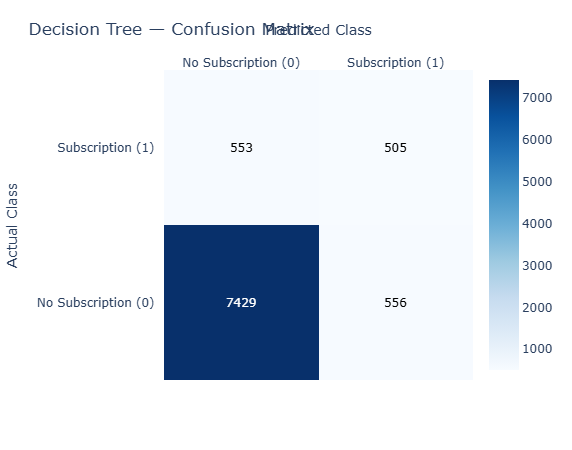

In [18]:
# Create interactive Decision Tree confusion matrix

tree_cm_labels = [
    "No Subscription (0)",
    "Subscription (1)"
]

fig = ff.create_annotated_heatmap(
    z=tree_cm,
    x=tree_cm_labels,
    y=tree_cm_labels,
    annotation_text=[
        [str(value) for value in row]
        for row in tree_cm
    ],
    colorscale="Blues",
    showscale=True
)

fig.update_layout(
    title="Decision Tree — Confusion Matrix",
    xaxis_title="Predicted Class",
    yaxis_title="Actual Class",
    width=650,
    height=450,
    margin=dict(l=70, r=30, t=70, b=70)
)

fig.show()

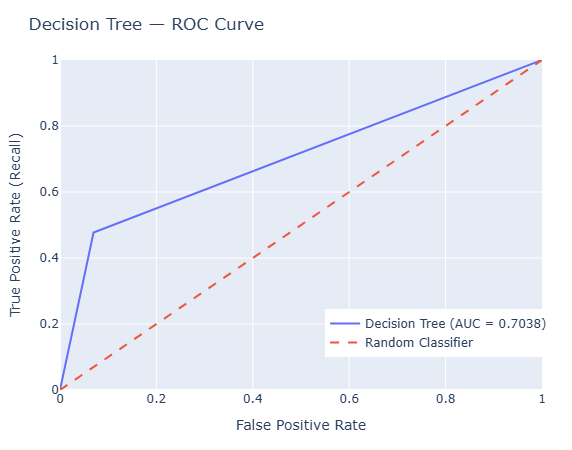

Decision Tree ROC-AUC: 0.7038


In [19]:
from sklearn.metrics import roc_curve

# Calculate ROC curve values
tree_fpr, tree_tpr, tree_thresholds = roc_curve(
    y_test,
    y_prob_tree
)

# Create interactive ROC curve
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=tree_fpr,
        y=tree_tpr,
        mode="lines",
        name=f"Decision Tree (AUC = {tree_roc_auc:.4f})",
        hovertemplate=(
            "False Positive Rate: %{x:.4f}<br>"
            "True Positive Rate: %{y:.4f}"
            "<extra></extra>"
        )
    )
)

# Random classifier reference line
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Random Classifier",
        line=dict(dash="dash")
    )
)

fig.update_layout(
    title="Decision Tree — ROC Curve",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate (Recall)",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
    width=700,
    height=450,
    margin=dict(l=60, r=30, t=60, b=60),
    legend=dict(
        x=0.55,
        y=0.10
    )
)

fig.show()

print(f"Decision Tree ROC-AUC: {tree_roc_auc:.4f}")

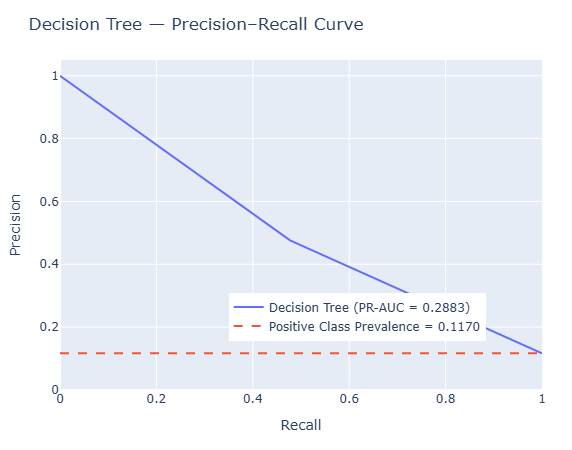

Decision Tree PR-AUC: 0.2883
Positive class prevalence: 0.1170


In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall values
tree_precision_curve, tree_recall_curve, tree_pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_prob_tree
    )
)

# Calculate PR-AUC / Average Precision
tree_pr_auc = average_precision_score(
    y_test,
    y_prob_tree
)

# Positive-class prevalence
positive_prevalence = y_test.mean()

# Create interactive Precision-Recall curve
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=tree_recall_curve,
        y=tree_precision_curve,
        mode="lines",
        name=f"Decision Tree (PR-AUC = {tree_pr_auc:.4f})",
        hovertemplate=(
            "Recall: %{x:.4f}<br>"
            "Precision: %{y:.4f}"
            "<extra></extra>"
        )
    )
)

# Positive-class prevalence reference
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[positive_prevalence, positive_prevalence],
        mode="lines",
        name=f"Positive Class Prevalence = {positive_prevalence:.4f}",
        line=dict(dash="dash")
    )
)

fig.update_layout(
    title="Decision Tree — Precision–Recall Curve",
    xaxis_title="Recall",
    yaxis_title="Precision",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.05]),
    width=700,
    height=450,
    margin=dict(l=60, r=30, t=60, b=60),
    legend=dict(
        x=0.35,
        y=0.15
    )
)

fig.show()

print(f"Decision Tree PR-AUC: {tree_pr_auc:.4f}")
print(f"Positive class prevalence: {positive_prevalence:.4f}")

In [21]:
# Create Decision Tree results row
decision_tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [tree_accuracy],
    "Precision": [tree_precision],
    "Recall": [tree_recall],
    "F1_Score": [tree_f1],
    "ROC_AUC": [tree_roc_auc],
    "PR_AUC": [tree_pr_auc],
    "Balanced_Accuracy": [tree_balanced_accuracy]
})

# Combine Logistic Regression and Decision Tree
baseline_results = pd.concat(
    [
        baseline_results,
        decision_tree_results
    ],
    ignore_index=True
)

print("=" * 80)
print("BASELINE MODEL COMPARISON")
print("=" * 80)

display(
    baseline_results.round(4)
)

BASELINE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Logistic Regression,0.9022,0.6543,0.3488,0.4550,0.9109,0.5591,0.6622
1,Decision Tree,0.8774,0.4760,0.4773,0.4766,0.7038,0.2883,0.7038


In [22]:
baseline_results_path = "../results/metrics/baseline_results.csv"

baseline_results.to_csv(
    baseline_results_path,
    index=False
)

print("\nUpdated baseline results saved successfully!")
print("File:", baseline_results_path)


Updated baseline results saved successfully!
File: ../results/metrics/baseline_results.csv


In [23]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest baseline model
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

# Train the model
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest baseline trained successfully!")

# Generate class predictions
y_pred_rf = random_forest_model.predict(X_test)

# Generate probability predictions
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("\nPredictions generated successfully!")

print("Number of predictions:", len(y_pred_rf))
print("Number of probability predictions:", len(y_prob_rf))

print("\nFirst 10 predicted classes:")
print(y_pred_rf[:10])

print("\nFirst 10 predicted probabilities:")
print(np.round(y_prob_rf[:10], 4))

Random Forest baseline trained successfully!

Predictions generated successfully!
Number of predictions: 9043
Number of probability predictions: 9043

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.09 0.01 0.   0.04 0.32 0.02 0.01 0.33 0.01 0.  ]


In [24]:
# Calculate Random Forest baseline metrics

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

rf_pr_auc = average_precision_score(
    y_test,
    y_prob_rf
)

rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_rf
)

# Confusion matrix
rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

# Display results
print("=" * 60)
print("RANDOM FOREST — BASELINE RESULTS")
print("=" * 60)

print(f"\nAccuracy:           {rf_accuracy:.4f}")
print(f"Precision:          {rf_precision:.4f}")
print(f"Recall:             {rf_recall:.4f}")
print(f"F1-score:           {rf_f1:.4f}")
print(f"ROC-AUC:            {rf_roc_auc:.4f}")
print(f"PR-AUC:             {rf_pr_auc:.4f}")
print(f"Balanced Accuracy:  {rf_balanced_accuracy:.4f}")

print("\nConfusion Matrix:")
print(rf_cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Subscription (0)",
            "Subscription (1)"
        ],
        zero_division=0
    )
)

RANDOM FOREST — BASELINE RESULTS

Accuracy:           0.9062
Precision:          0.6636
Recall:             0.4026
F1-score:           0.5012
ROC-AUC:            0.9352
PR-AUC:             0.6177
Balanced Accuracy:  0.6878

Confusion Matrix:
[[7769  216]
 [ 632  426]]

Classification Report:
                     precision    recall  f1-score   support

No Subscription (0)       0.92      0.97      0.95      7985
   Subscription (1)       0.66      0.40      0.50      1058

           accuracy                           0.91      9043
          macro avg       0.79      0.69      0.72      9043
       weighted avg       0.89      0.91      0.90      9043



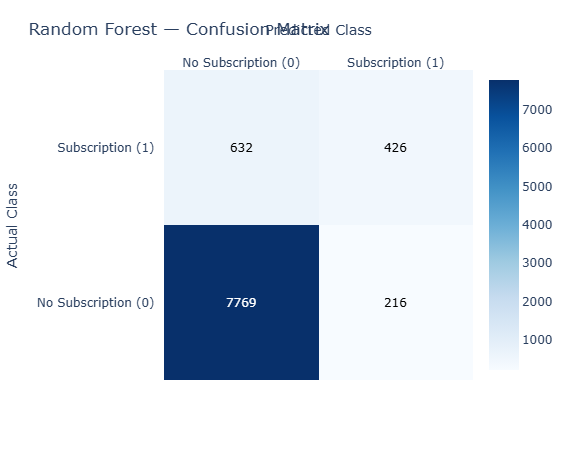

In [25]:
# Create interactive Random Forest confusion matrix

rf_cm_labels = [
    "No Subscription (0)",
    "Subscription (1)"
]

fig = ff.create_annotated_heatmap(
    z=rf_cm,
    x=rf_cm_labels,
    y=rf_cm_labels,
    annotation_text=[
        [str(value) for value in row]
        for row in rf_cm
    ],
    colorscale="Blues",
    showscale=True
)

fig.update_layout(
    title="Random Forest — Confusion Matrix",
    xaxis_title="Predicted Class",
    yaxis_title="Actual Class",
    width=650,
    height=450,
    margin=dict(l=70, r=30, t=70, b=70)
)

fig.show()

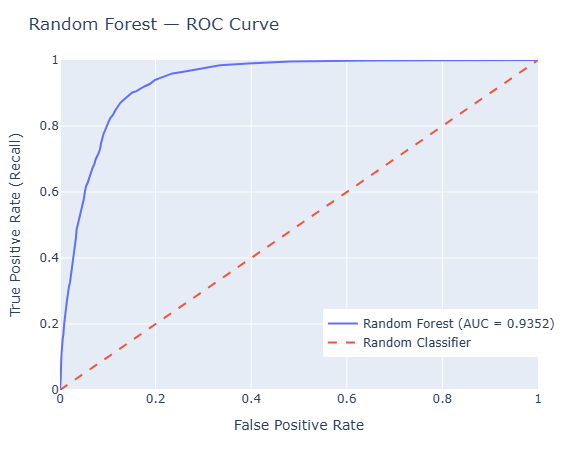

Random Forest ROC-AUC: 0.9352


In [26]:
from sklearn.metrics import roc_curve

# Calculate ROC curve values
rf_fpr, rf_tpr, rf_thresholds = roc_curve(
    y_test,
    y_prob_rf
)

# Create interactive ROC curve
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=rf_fpr,
        y=rf_tpr,
        mode="lines",
        name=f"Random Forest (AUC = {rf_roc_auc:.4f})",
        hovertemplate=(
            "False Positive Rate: %{x:.4f}<br>"
            "True Positive Rate: %{y:.4f}"
            "<extra></extra>"
        )
    )
)

# Random classifier reference line
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Random Classifier",
        line=dict(dash="dash")
    )
)

fig.update_layout(
    title="Random Forest — ROC Curve",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate (Recall)",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
    width=700,
    height=450,
    margin=dict(l=60, r=30, t=60, b=60),
    legend=dict(
        x=0.55,
        y=0.10
    )
)

fig.show()

print(f"Random Forest ROC-AUC: {rf_roc_auc:.4f}")

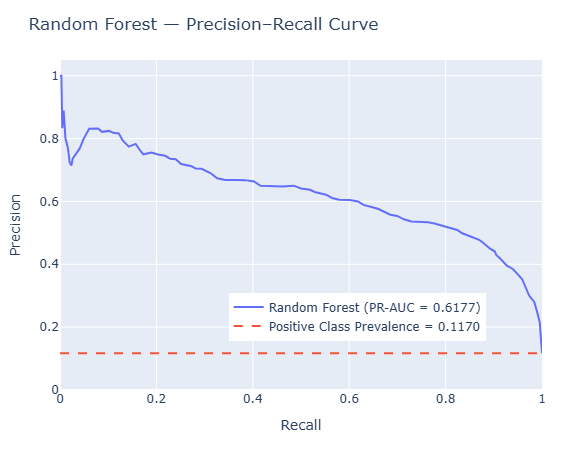

Random Forest PR-AUC: 0.6177
Positive class prevalence: 0.1170


In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall values
rf_precision_curve, rf_recall_curve, rf_pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_prob_rf
    )
)

# Calculate PR-AUC / Average Precision
rf_pr_auc = average_precision_score(
    y_test,
    y_prob_rf
)

# Positive-class prevalence
positive_prevalence = y_test.mean()

# Create interactive Precision-Recall curve
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=rf_recall_curve,
        y=rf_precision_curve,
        mode="lines",
        name=f"Random Forest (PR-AUC = {rf_pr_auc:.4f})",
        hovertemplate=(
            "Recall: %{x:.4f}<br>"
            "Precision: %{y:.4f}"
            "<extra></extra>"
        )
    )
)

# Positive-class prevalence reference
fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[positive_prevalence, positive_prevalence],
        mode="lines",
        name=f"Positive Class Prevalence = {positive_prevalence:.4f}",
        line=dict(dash="dash")
    )
)

fig.update_layout(
    title="Random Forest — Precision–Recall Curve",
    xaxis_title="Recall",
    yaxis_title="Precision",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.05]),
    width=700,
    height=450,
    margin=dict(l=60, r=30, t=60, b=60),
    legend=dict(
        x=0.35,
        y=0.15
    )
)

fig.show()

print(f"Random Forest PR-AUC: {rf_pr_auc:.4f}")
print(f"Positive class prevalence: {positive_prevalence:.4f}")

In [28]:
# Create Random Forest results row
random_forest_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [rf_accuracy],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "F1_Score": [rf_f1],
    "ROC_AUC": [rf_roc_auc],
    "PR_AUC": [rf_pr_auc],
    "Balanced_Accuracy": [rf_balanced_accuracy]
})

# Add Random Forest to the existing baseline results
baseline_results = pd.concat(
    [
        baseline_results,
        random_forest_results
    ],
    ignore_index=True
)

print("=" * 90)
print("STAGE 4 — BASELINE MODEL COMPARISON")
print("=" * 90)

display(
    baseline_results.round(4)
)

STAGE 4 — BASELINE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy
0,Logistic Regression,0.9022,0.6543,0.3488,0.4550,0.9109,0.5591,0.6622
1,Decision Tree,0.8774,0.4760,0.4773,0.4766,0.7038,0.2883,0.7038
2,Random Forest,0.9062,0.6636,0.4026,0.5012,0.9352,0.6177,0.6878


In [29]:
baseline_results_path = "../results/metrics/baseline_results.csv"

baseline_results.to_csv(
    baseline_results_path,
    index=False
)

print("\nComplete baseline results saved successfully!")
print("File:", baseline_results_path)


Complete baseline results saved successfully!
File: ../results/metrics/baseline_results.csv


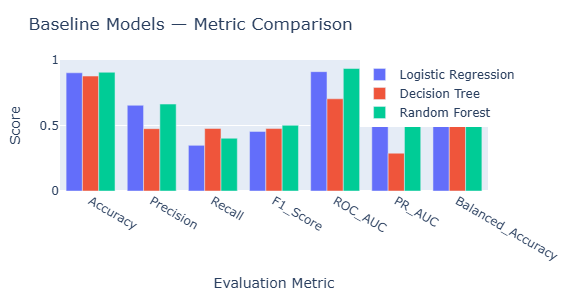

In [32]:
import plotly.graph_objects as go

# Metrics we want to compare
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC",
    "PR_AUC",
    "Balanced_Accuracy"
]

fig = go.Figure()

for _, row in baseline_results.iterrows():
    fig.add_trace(
        go.Bar(
            name=row["Model"],
            x=metrics_to_plot,
            y=[row[metric] for metric in metrics_to_plot],
            hovertemplate=(
                "Metric: %{x}<br>"
                "Score: %{y:.4f}"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Baseline Models — Metric Comparison",
    xaxis_title="Evaluation Metric",
    yaxis_title="Score",
    yaxis=dict(range=[0, 1]),
    barmode="group",
    width=500,
    height=300,
    margin=dict(l=60, r=30, t=60, b=70),
    legend=dict(
        x=0.70,
        y=1.0
    )
)

fig.show()

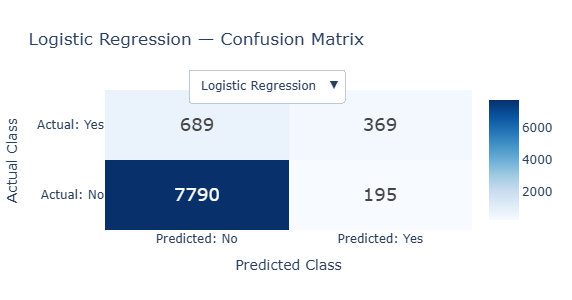

In [34]:
import plotly.graph_objects as go

# Store confusion matrices
confusion_matrices = {
    "Logistic Regression": logistic_cm,
    "Decision Tree": tree_cm,
    "Random Forest": rf_cm
}

# Create one heatmap containing all three matrices
fig = go.Figure()

# Add each model as a separate heatmap trace
for model_name, cm in confusion_matrices.items():

    # Create annotation text
    annotation_text = [
        [str(cm[0, 0]), str(cm[0, 1])],
        [str(cm[1, 0]), str(cm[1, 1])]
    ]

    fig.add_trace(
        go.Heatmap(
            z=cm,
            x=["Predicted: No", "Predicted: Yes"],
            y=["Actual: No", "Actual: Yes"],
            text=annotation_text,
            texttemplate="%{text}",
            textfont=dict(size=18),
            colorscale="Blues",
            visible=(model_name == "Logistic Regression"),
            hovertemplate=(
                "Actual: %{y}<br>"
                "Predicted: %{x}<br>"
                "Count: %{z}<extra></extra>"
            ),
            showscale=True
        )
    )

# Dropdown menu to switch between models
buttons = []

model_names = list(confusion_matrices.keys())

for i, model_name in enumerate(model_names):

    visibility = [False] * len(model_names)
    visibility[i] = True

    buttons.append(
        dict(
            label=model_name,
            method="update",
            args=[
                {"visible": visibility},
                {
                    "title": f"{model_name} — Confusion Matrix"
                }
            ]
        )
    )

fig.update_layout(
    title="Logistic Regression — Confusion Matrix",
    xaxis_title="Predicted Class",
    yaxis_title="Actual Class",
    width=500,
    height=300,
    margin=dict(l=70, r=30, t=90, b=70),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.65,
            y=1.15
        )
    ]
)

fig.show()

In [35]:
from sklearn.metrics import classification_report

# Classification report — Logistic Regression
print("=" * 80)
print("LOGISTIC REGRESSION — CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "No Subscription (0)",
            "Subscription (1)"
        ],
        digits=4,
        zero_division=0
    )
)


# Classification report — Decision Tree
print("=" * 80)
print("DECISION TREE — CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=[
            "No Subscription (0)",
            "Subscription (1)"
        ],
        digits=4,
        zero_division=0
    )
)


# Classification report — Random Forest
print("=" * 80)
print("RANDOM FOREST — CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Subscription (0)",
            "Subscription (1)"
        ],
        digits=4,
        zero_division=0
    )
)

LOGISTIC REGRESSION — CLASSIFICATION REPORT
                     precision    recall  f1-score   support

No Subscription (0)     0.9187    0.9756    0.9463      7985
   Subscription (1)     0.6543    0.3488    0.4550      1058

           accuracy                         0.9022      9043
          macro avg     0.7865    0.6622    0.7007      9043
       weighted avg     0.8878    0.9022    0.8888      9043

DECISION TREE — CLASSIFICATION REPORT
                     precision    recall  f1-score   support

No Subscription (0)     0.9307    0.9304    0.9305      7985
   Subscription (1)     0.4760    0.4773    0.4766      1058

           accuracy                         0.8774      9043
          macro avg     0.7033    0.7038    0.7036      9043
       weighted avg     0.8775    0.8774    0.8774      9043

RANDOM FOREST — CLASSIFICATION REPORT
                     precision    recall  f1-score   support

No Subscription (0)     0.9248    0.9729    0.9482      7985
   Subscription (1)

In [36]:
# Generate classification reports as dictionaries
logistic_report = classification_report(
    y_test,
    y_pred_logistic,
    output_dict=True,
    zero_division=0
)

tree_report = classification_report(
    y_test,
    y_pred_tree,
    output_dict=True,
    zero_division=0
)

rf_report = classification_report(
    y_test,
    y_pred_rf,
    output_dict=True,
    zero_division=0
)

# Extract minority-class (class 1) metrics
minority_class_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Minority_Precision": [
        logistic_report["1"]["precision"],
        tree_report["1"]["precision"],
        rf_report["1"]["precision"]
    ],
    "Minority_Recall": [
        logistic_report["1"]["recall"],
        tree_report["1"]["recall"],
        rf_report["1"]["recall"]
    ],
    "Minority_F1": [
        logistic_report["1"]["f1-score"],
        tree_report["1"]["f1-score"],
        rf_report["1"]["f1-score"]
    ],
    "Minority_Support": [
        logistic_report["1"]["support"],
        tree_report["1"]["support"],
        rf_report["1"]["support"]
    ]
})

print("=" * 90)
print("MINORITY CLASS (SUBSCRIPTION = 1) PERFORMANCE")
print("=" * 90)

display(
    minority_class_results.round(4)
)

MINORITY CLASS (SUBSCRIPTION = 1) PERFORMANCE


,Model,Minority_Precision,Minority_Recall,Minority_F1,Minority_Support
0,Logistic Regression,0.6543,0.3488,0.4550,1058.0
1,Decision Tree,0.4760,0.4773,0.4766,1058.0
2,Random Forest,0.6636,0.4026,0.5012,1058.0


In [37]:
minority_results_path = "../results/metrics/minority_class_results.csv"

minority_class_results.to_csv(
    minority_results_path,
    index=False
)

print("\nMinority-class results saved successfully!")
print("File:", minority_results_path)


Minority-class results saved successfully!
File: ../results/metrics/minority_class_results.csv


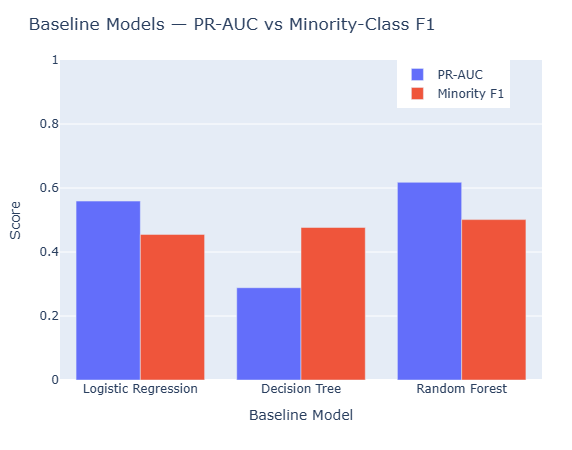

PR-AUC VS MINORITY F1


,Model,PR_AUC,Minority_F1
0,Logistic Regression,0.5591,0.4550
1,Decision Tree,0.2883,0.4766
2,Random Forest,0.6177,0.5012


In [38]:
import plotly.graph_objects as go

# Prepare comparison data
comparison_data = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "PR_AUC": [
        logistic_pr_auc,
        tree_pr_auc,
        rf_pr_auc
    ],
    "Minority_F1": [
        logistic_report["1"]["f1-score"],
        tree_report["1"]["f1-score"],
        rf_report["1"]["f1-score"]
    ]
})

# Create grouped bar chart
fig = go.Figure()

fig.add_trace(
    go.Bar(
        name="PR-AUC",
        x=comparison_data["Model"],
        y=comparison_data["PR_AUC"],
        hovertemplate=(
            "Model: %{x}<br>"
            "PR-AUC: %{y:.4f}"
            "<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Bar(
        name="Minority F1",
        x=comparison_data["Model"],
        y=comparison_data["Minority_F1"],
        hovertemplate=(
            "Model: %{x}<br>"
            "Minority F1: %{y:.4f}"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="Baseline Models — PR-AUC vs Minority-Class F1",
    xaxis_title="Baseline Model",
    yaxis_title="Score",
    yaxis=dict(range=[0, 1]),
    barmode="group",
    width=750,
    height=450,
    margin=dict(l=60, r=30, t=60, b=70),
    legend=dict(
        x=0.70,
        y=1.0
    )
)

fig.show()

print("=" * 80)
print("PR-AUC VS MINORITY F1")
print("=" * 80)

display(
    comparison_data.round(4)
)

In [39]:
# Create final baseline summary

final_baseline_summary = baseline_results.copy()

# Add minority-class metrics
final_baseline_summary["Minority_Precision"] = (
    minority_class_results["Minority_Precision"].values
)

final_baseline_summary["Minority_Recall"] = (
    minority_class_results["Minority_Recall"].values
)

final_baseline_summary["Minority_F1"] = (
    minority_class_results["Minority_F1"].values
)

print("=" * 110)
print("FINAL BASELINE MODEL SUMMARY")
print("=" * 110)

display(
    final_baseline_summary.round(4)
)

FINAL BASELINE MODEL SUMMARY


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC,Balanced_Accuracy,Minority_Precision,Minority_Recall,Minority_F1
0,Logistic Regression,0.9022,0.6543,0.3488,0.4550,0.9109,0.5591,0.6622,0.6543,0.3488,0.4550
1,Decision Tree,0.8774,0.4760,0.4773,0.4766,0.7038,0.2883,0.7038,0.4760,0.4773,0.4766
2,Random Forest,0.9062,0.6636,0.4026,0.5012,0.9352,0.6177,0.6878,0.6636,0.4026,0.5012


In [40]:
print("=" * 100)
print("STAGE 4 — BASELINE MODELS: FINAL VALIDATION")
print("=" * 100)

# ---------------------------------------------------------
# 1. Verify that all three models are present
# ---------------------------------------------------------

expected_models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

actual_models = final_baseline_summary["Model"].tolist()

print("\n1. Models included:")
for model in expected_models:
    status = "✓" if model in actual_models else "✗"
    print(f"{status} {model}")


# ---------------------------------------------------------
# 2. Verify required metrics
# ---------------------------------------------------------

required_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC",
    "PR_AUC",
    "Balanced_Accuracy",
    "Minority_Precision",
    "Minority_Recall",
    "Minority_F1"
]

print("\n2. Required metrics:")

for metric in required_metrics:
    status = "✓" if metric in final_baseline_summary.columns else "✗"
    print(f"{status} {metric}")


# ---------------------------------------------------------
# 3. Check for missing metric values
# ---------------------------------------------------------

missing_values = final_baseline_summary[required_metrics].isna().sum()

print("\n3. Missing metric values:")

if missing_values.sum() == 0:
    print("✓ No missing metric values found.")
else:
    print(missing_values[missing_values > 0])


# ---------------------------------------------------------
# 4. Check metric ranges
# ---------------------------------------------------------

metric_range_check = (
    final_baseline_summary[required_metrics]
    .apply(lambda column: column.between(0, 1).all())
)

print("\n4. Metric range validation:")

if metric_range_check.all():
    print("✓ All performance metrics are between 0 and 1.")
else:
    print(
        metric_range_check[
            metric_range_check == False
        ]
    )


# ---------------------------------------------------------
# 5. Check output files
# ---------------------------------------------------------

import os

output_files = [
    "../results/metrics/baseline_results.csv",
    "../results/metrics/minority_class_results.csv",
    "../results/metrics/final_baseline_summary.csv"
]

print("\n5. Saved result files:")

for file_path in output_files:
    if os.path.exists(file_path):
        print(f"✓ {file_path}")
    else:
        print(f"✗ Missing: {file_path}")


# ---------------------------------------------------------
# 6. Final summary
# ---------------------------------------------------------

print("\n" + "=" * 100)
print("STAGE 4 COMPLETE")
print("=" * 100)

print("""
Baseline experimentation has been completed.

Models evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Evaluation includes:
• Accuracy
• Precision
• Recall
• F1-score
• ROC-AUC
• PR-AUC
• Balanced Accuracy
• Minority-class Precision
• Minority-class Recall
• Minority-class F1-score
• Confusion matrices
• ROC curves
• Precision-Recall curves

No hyperparameter optimization was performed.
No SMOTE was applied.
No class weighting was applied.
No threshold optimization was performed.

Therefore, these results represent the original baseline
performance on the imbalanced Bank Marketing dataset.
""")

STAGE 4 — BASELINE MODELS: FINAL VALIDATION

1. Models included:
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest

2. Required metrics:
✓ Accuracy
✓ Precision
✓ Recall
✓ F1_Score
✓ ROC_AUC
✓ PR_AUC
✓ Balanced_Accuracy
✓ Minority_Precision
✓ Minority_Recall
✓ Minority_F1

3. Missing metric values:
✓ No missing metric values found.

4. Metric range validation:
✓ All performance metrics are between 0 and 1.

5. Saved result files:
✓ ../results/metrics/baseline_results.csv
✓ ../results/metrics/minority_class_results.csv
✗ Missing: ../results/metrics/final_baseline_summary.csv

STAGE 4 COMPLETE

Baseline experimentation has been completed.

Models evaluated:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Evaluation includes:
• Accuracy
• Precision
• Recall
• F1-score
• ROC-AUC
• PR-AUC
• Balanced Accuracy
• Minority-class Precision
• Minority-class Recall
• Minority-class F1-score
• Confusion matrices
• ROC curves
• Precision-Recall curves

No hyperparameter optimization was